In [1]:
import pysr
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

[juliapkg] Found dependencies: /glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/pysr/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.12.1 to /glade/work/cobrien/conda-envs/pt212gpu_conda/julia_env/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia from https://julialang-s3.julialang.or

  Installing known registries into `~/.julia`
       Added `General` registry to ~/.julia/registries
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Scratch ───────────────────── v1.3.0
   Installed IrrationalConstants ───────── v0.2.6
   Installed ScientificTypesBase ───────── v3.0.0
   Installed Adapt ─────────────────────── v4.4.0
   Installed Tricks ────────────────────── v0.1.12
   Installed DiffRules ─────────────────── v1.15.1
   Installed MicroMamba ────────────────── v0.1.14
   Installed DynamicExpressions ────────── v1.10.3
   Installed PtrArrays ─────────────────── v1.3.0
   Installed TableTraits ───────────────── v1.0.1
   Installed DiffResults ───────────────── v1.1.0
   Installed JSON3 ─────────────────────── v1.14.3
   Installed ADTypes ───────────────────── v1.18.0
   Installed Preferences ───────────────── v1.5.0
   Installed MLJModelInterface ─────────── v1.11.1
   Installed StatisticalTraits ─────────── v3.5.0

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [8]:
np.random.seed(0)
N = 3000
upper_sigma = 5
X = 2 * np.random.rand(N, 5)
sigma = np.random.rand(N) * (5 - 0.1) + 0.1
eps = sigma * np.random.randn(N)
y = 5 * np.cos(3.5 * X[:, 0]) - 1.3 + eps

Text(0, 0.5, '$y$')

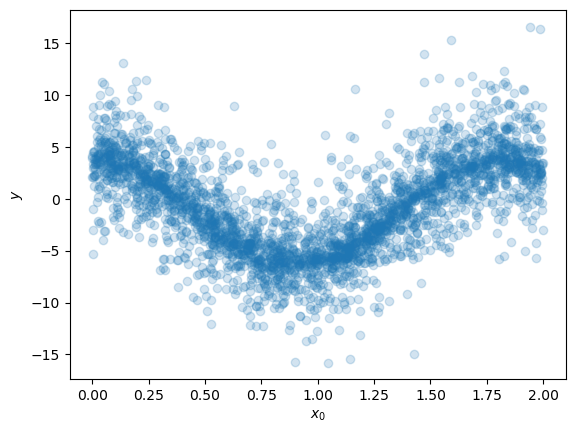

In [9]:
plt.scatter(X[:, 0], y, alpha=0.2)
plt.xlabel("$x_0$")
plt.ylabel("$y$")

In [10]:
weights = 1 / sigma**2
weights[:5]

array([0.25199296, 0.0775419 , 0.11515701, 0.1781281 , 0.0448131 ])

In [16]:
model = PySRRegressor(
    elementwise_loss="myloss(x, y, w) = w * abs(x - y)",  # Custom loss function with weights.
    niterations=20,
    populations=20,  # Use more populations
    binary_operators=["+", "*"],
    unary_operators=["cos"],
    # denoise=True,
)
model.fit(X, y, weights=weights)

/glade/work/cobrien/conda-envs/pt212gpu_conda/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.240e+03
Progress: 8 / 400 total iterations (2.000%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           3.607e+00  0.000e+00  y = 1.2553
3           3.279e+00  4.762e-02  y = x₀ * x₀
5           3.189e+00  1.392e-02  y = (x₀ + -1.4166) + -0.31219
6           3.146e+00  1.344e-02  y = -1.365 * (x₂ * cos(x₀))
7           2.949e+00  6.462e-02  y = (1.8834 + x₀) * (x₀ + -1.0462)
8           9.693e-01  1.113e+00  y = (cos(x₀ * 3.4916) * 4.626) + -0.38465
10          5.025e-01  3.285e-01  y = ((cos(x₀ * 3.4916) * 2.3745) + -0.71717) * 2.2655
12          3.126e-01  2.373e-01  y = (((cos(x₀ * 3.4956) * 2.3427) + -0.41511) * 2.1495) + ...
                                      -0.39278
──────────────────────────────────────────────────────────────────────────

[ Info: Final population:
[ Info: Results saved to:


,model_selection,'best'
,binary_operators,"['+', '*']"
,unary_operators,['cos']
,expression_spec,None
,niterations,20
,populations,20
,population_size,27
,max_evals,None
,maxsize,30
,maxdepth,None
,warmup_maxsize_by,None


  - outputs/20251030_095857_W3Xbnp/hall_of_fame.csv


In [17]:
best_idx = model.equations_.query(
    f"loss < {2 * model.equations_.loss.min()}"
).score.idxmax()
model.sympy(best_idx)

cos(x0*3.4957678)*5.0275497 - 1.2882255

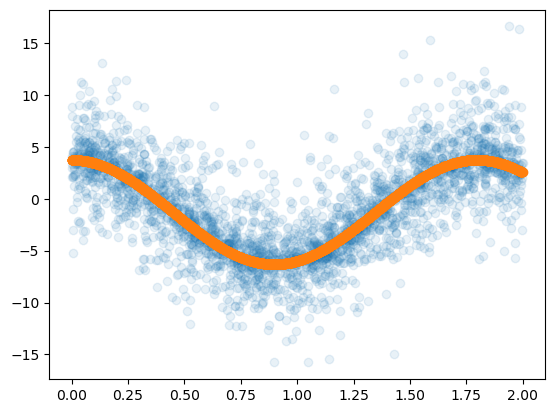

In [18]:
plt.scatter(X[:, 0], y, alpha=0.1)
y_prediction = model.predict(X, index=best_idx)
plt.scatter(X[:, 0], y_prediction)